<a href="https://colab.research.google.com/github/raju-cse/Flyrank-internship_ml/blob/main/work/notebooks/w07_action_playbook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This notebook converts the validated ML output into a practical, human-reviewed content action playbook. It is designed for prioritization and research use, not autonomous production decisions.


## 1. Setup and data discovery

The notebook first looks for reusable Week 5/6 artifacts. If a prediction/score file is available, it uses it; otherwise it reconstructs a lightweight queue from the available processed dataset and documented model outputs. No synthetic model metrics are introduced.


ML-10 — CONTENT ACTION PLAYBOOK
Repository already exists.

Repository:
/content/Flyrank-internship_ml

Repository checks:
OK       work/notebooks/w05_model.ipynb
OK       work/notebooks/w06_validation_audit.ipynb
OK       work/notebooks/w07_action_playbook.ipynb

Main dataset:
data/raw/content_refresh_anonymized.csv

DATASET
Shape: (30000, 44)

Columns:
  1. content_id
  2. client_id
  3. search_volume
  4. competition
  5. competition_level
  6. cpc
  7. content_type
  8. main_intent
  9. word_count
 10. char_count
 11. provider_used
 12. model_used
 13. impressions_90d
 14. clicks_90d
 15. pageviews_90d
 16. sessions_90d
 17. users_90d
 18. engaged_sessions_90d
 19. ai_sessions_90d
 20. scroll_events_90d
 21. days_with_impressions
 22. days_with_sessions
 23. impressions_last_30d
 24. clicks_last_30d
 25. sessions_last_30d
 26. impressions_prev_30d
 27. clicks_prev_30d
 28. sessions_prev_30d
 29. content_age_days
 30. age_tier
 31. age_tier_order
 32. days_since_last_update
 33. fre

,column,dtype,missing,unique
0,content_id,object,0,30000
1,client_id,object,0,32
2,search_volume,float64,2468,41
3,competition,float64,2468,101
4,competition_level,object,2610,3
5,cpc,float64,2468,915
6,content_type,object,0,3
7,main_intent,object,2374,4
8,word_count,float64,7699,5476
9,char_count,float64,7699,14839



REFERENCE REFRESH QUEUE
Path: outputs/refresh_queue_sample.csv
Shape: (200, 28)

Columns:
 - final_rank
 - content_id
 - client_id
 - final_refresh_score
 - best_model_name
 - best_model_probability
 - baseline_refresh_score
 - confidence
 - suggested_action
 - final_reason_codes
 - is_declining_label
 - impressions_90d
 - clicks_90d
 - sessions_90d
 - avg_position
 - ctr
 - content_age_days
 - days_since_last_update
 - word_count
 - trend_direction
 - competition_level
 - content_type
 - main_intent
 - age_tier
 - freshness_tier
 - word_count_tier
 - impression_tier
 - position_tier

Preview:


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1



TARGET DETECTION
Detected target: trend_direction

Target distribution:


...


Recommended actions:


,recommended_action,items
0,Prioritize for human content review,11757
1,Review content relevance and search optimization,7508
2,Refresh/review content first,5551
3,Review content freshness and update opportunity,5184



CONTENT ARCHETYPE SUMMARY


,content_type,items,best_rank,mean_priority,suggested_action
2,keyword article,27207,1,0.547494,Monitor / review when capacity allows
1,feedly article,2096,1967,0.280537,Monitor / review when capacity allows
0,comparison article,697,2724,0.587080,Monitor / review when capacity allows



DECAY / FRESHNESS ANALYSIS
Correlation between days_since_last_update and priority score: 0.1061


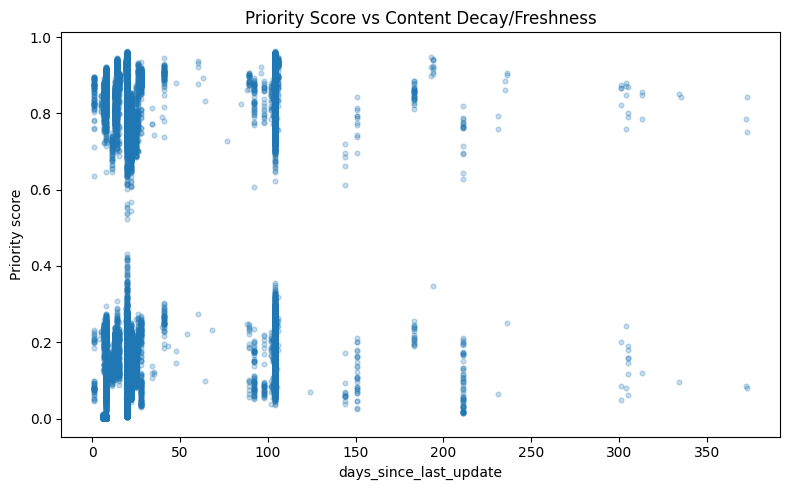

Saved: /content/Flyrank-internship_ml/work/figures/w07_priority_vs_decay.png

COST / VALUE PRIORITIZATION


,metric,value
0,total_items,30000.000000
1,top_50_review_items,50.000000
2,top_50_share,0.001667
3,mean_top_50_score,0.959032
4,mean_all_score,0.529762




HUMAN REVIEW RULES

The ranked queue is a decision-support artifact,
not an autonomous publishing system.

Human review is required before:

1. Refreshing or materially changing content.
2. Publishing any model-informed change.
3. Acting on unusually high-priority items.
4. Acting on low-confidence or ambiguous cases.
5. Making decisions with significant business impact.

The reviewer should check current content quality,
business context, search intent, and relevant constraints
before taking action.


NO-GO / WHAT SHOULD NOT BE AUTOMATED

The system should NOT autonomously:

- Publish content.
- Delete content.
- Replace important content.
- Make high-impact business decisions.
- Override editorial judgment.
- Treat model ranking as causal evidence.
- Act on sensitive or exceptional cases without review.

The ranking is used only to prioritize human investigation.



MONITORING AND RETRAINING TRIGGERS

Signal:
Ranking quality
Trigger:
Performance drops below validated baseline
Respo

,main_intent,content_type,client_id,content_id,rank,priority_score,priority_band,reason_code,recommended_action
0,informational,keyword article,client_7f2253d7e2,content_82ea9307e1ab,1,0.964316,TOP_50,WEAK_SEARCH_POSITION,Review content relevance and search optimization
1,transactional,keyword article,client_3fdba35f04,content_8dba22b835f8,2,0.963942,TOP_50,STALE_OR_DECAYING,Refresh/review content first
2,transactional,keyword article,client_3fdba35f04,content_4ad7d80e0a11,3,0.961821,TOP_50,WEAK_SEARCH_POSITION,Review content relevance and search optimization
3,transactional,keyword article,client_7f2253d7e2,content_3585f0ab30e6,4,0.961741,TOP_50,MODEL_OR_PRIORITY_SIGNAL,Prioritize for human content review
4,commercial,keyword article,client_7f2253d7e2,content_9e4b7cc63012,5,0.961410,TOP_50,WEAK_SEARCH_POSITION,Review content relevance and search optimization
5,informational,keyword article,client_3fdba35f04,content_83fcdbd947c9,6,0.960941,TOP_50,MODEL_OR_PRIORITY_SIGNAL,Prioritize for human content review
6,commercial,keyword article,client_7f2253d7e2,content_7f12daa9fcef,7,0.960661,TOP_50,MODEL_OR_PRIORITY_SIGNAL,Prioritize for human content review
7,informational,keyword article,client_3fdba35f04,content_d840a3a6302b,8,0.960650,TOP_50,WEAK_SEARCH_POSITION,Review content relevance and search optimization
8,commercial,keyword article,client_7f2253d7e2,content_9e3689ef2df5,9,0.960347,TOP_50,WEAK_SEARCH_POSITION,Review content relevance and search optimization
9,informational,keyword article,client_3fdba35f04,content_ae53827c2894,10,0.960096,TOP_50,STALE_OR_DECAYING,Refresh/review content first



Metrics exported:
/content/Flyrank-internship_ml/work/outputs/w07_action_playbook_metrics.json

FINAL SELF-CHECK


,check,passed
0,repository_found,True
1,main_dataset_found,True
2,data_loaded,True
3,priority_score_created,True
4,rank_created,True
5,priority_band_created,True
6,reason_codes_created,True
7,actions_created,True
8,queue_exported,True
9,metrics_exported,True




ML-10 SELF-CHECK PASSED

Generated files:
 - work/outputs/w07_ranked_action_queue.csv
 - work/outputs/w07_action_playbook_metrics.json
 - work/figures/w07_priority_vs_decay.png

Score source:
Random Forest predicted probability using documented target

Dataset used:
data/raw/content_refresh_anonymized.csv

Done.


In [37]:
# ============================================================
# ML-10 — Content Action Playbook
# COMPLETE NOTEBOOK — SINGLE FILE VERSION
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

# ============================================================
# 1. REPOSITORY SETUP
# ============================================================

REPO_URL = "https://github.com/raju-cse/Flyrank-internship_ml.git"
ROOT = Path("/content/Flyrank-internship_ml")

print("=" * 70)
print("ML-10 — CONTENT ACTION PLAYBOOK")
print("=" * 70)

# Clone repository if necessary
if not ROOT.exists():

    import subprocess

    print("Cloning FlyRank repository...")

    result = subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(ROOT),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("Git clone failed.")

else:
    print("Repository already exists.")

# Required folders
WORK = ROOT / "work"
NOTEBOOKS = WORK / "notebooks"

OUT = WORK / "outputs"
FIG = WORK / "figures"

OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

print("\nRepository:")
print(ROOT)

# ============================================================
# 2. VERIFY REPOSITORY
# ============================================================

required_files = [
    NOTEBOOKS / "w05_model.ipynb",
    NOTEBOOKS / "w06_validation_audit.ipynb",
    NOTEBOOKS / "w07_action_playbook.ipynb",
]

print("\nRepository checks:")

for path in required_files:

    status = "OK" if path.exists() else "MISSING"

    print(
        f"{status:8}",
        path.relative_to(ROOT)
    )

# ============================================================
# 3. USE ACTUAL DATASET
# ============================================================

FEATURE_PATH = (
    ROOT /
    "data" /
    "raw" /
    "content_refresh_anonymized.csv"
)

SAMPLE_QUEUE_PATH = (
    ROOT /
    "outputs" /
    "refresh_queue_sample.csv"
)

if not FEATURE_PATH.exists():

    raise FileNotFoundError(
        f"""
Main dataset was not found:

{FEATURE_PATH}

Expected:
data/raw/content_refresh_anonymized.csv
"""
    )

print("\nMain dataset:")
print(FEATURE_PATH.relative_to(ROOT))

# ============================================================
# 4. LOAD DATA
# ============================================================

data = pd.read_csv(FEATURE_PATH)

print("\n" + "=" * 70)
print("DATASET")
print("=" * 70)

print("Shape:", data.shape)

print("\nColumns:")

for i, column in enumerate(data.columns, 1):
    print(f"{i:3}. {column}")

# ============================================================
# 5. BASIC DATA QUALITY CHECK
# ============================================================

quality = pd.DataFrame({
    "column": data.columns,
    "dtype": [
        str(data[c].dtype)
        for c in data.columns
    ],
    "missing": [
        int(data[c].isna().sum())
        for c in data.columns
    ],
    "unique": [
        int(data[c].nunique(dropna=True))
        for c in data.columns
    ],
})

print("\nData quality:")
display(quality)

# ============================================================
# 6. INSPECT SAMPLE QUEUE
# ============================================================

sample = None

if SAMPLE_QUEUE_PATH.exists():

    sample = pd.read_csv(
        SAMPLE_QUEUE_PATH
    )

    print("\n" + "=" * 70)
    print("REFERENCE REFRESH QUEUE")
    print("=" * 70)

    print(
        "Path:",
        SAMPLE_QUEUE_PATH.relative_to(ROOT)
    )

    print(
        "Shape:",
        sample.shape
    )

    print("\nColumns:")

    for column in sample.columns:
        print(" -", column)

    print("\nPreview:")

    display(sample.head())

# ============================================================
# 7. TARGET DETECTION
# ============================================================

TARGET_CANDIDATES = [
    "is_declining_label",
    "declining_label",
    "is_declining",
    "declining",
    "target",
    "label",
    "trend_direction",
    "refresh_label",
    "refresh_needed",
]

TARGET = None

for candidate in TARGET_CANDIDATES:

    if candidate in data.columns:

        TARGET = candidate
        break

print("\n" + "=" * 70)
print("TARGET DETECTION")
print("=" * 70)

print("Detected target:", TARGET)

# ============================================================
# 8. HANDLE TARGET
# ============================================================

y = None

if TARGET is not None:

    raw_target = data[TARGET]

    # --------------------------------------------------------
    # Numeric target
    # --------------------------------------------------------

    if pd.api.types.is_numeric_dtype(raw_target):

        y = pd.to_numeric(
            raw_target,
            errors="coerce"
        )

    # --------------------------------------------------------
    # String / categorical target
    # --------------------------------------------------------

    else:

        normalized = (
            raw_target
            .astype(str)
            .str.strip()
            .str.lower()
        )

        positive_values = {
            "1",
            "true",
            "yes",
            "y",
            "down",
            "declining",
            "decline",
            "refresh",
            "refresh_needed",
            "needs_refresh",
        }

        y = normalized.isin(
            positive_values
        ).astype(int)

    y = (
        pd.to_numeric(
            y,
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )

    # Normalize unexpected numeric values
    y = (y > 0).astype(int)

    print("\nTarget distribution:")

    display(
        y.value_counts()
        .rename_axis("target")
        .reset_index(name="count")
    )

    print(
        "\nPositive target rate:",
        round(float(y.mean()), 4)
    )

else:

    print(
        """
No documented target column was found in the main dataset.

The notebook will NOT invent a target or create fake labels.

We will inspect the available fields and the reference
refresh queue to determine whether a documented priority
field can be used.
"""
    )

# ============================================================
# 9. FEATURE DISCOVERY
# ============================================================

EXCLUDE_COLUMNS = {
    TARGET,
    "content_id",
    "id",
    "url",
}

EXCLUDE_COLUMNS = {
    x for x in EXCLUDE_COLUMNS
    if x is not None
}

numeric_columns = [
    c
    for c in data.select_dtypes(
        include=np.number
    ).columns
    if c not in EXCLUDE_COLUMNS
]

categorical_columns = [
    c
    for c in data.select_dtypes(
        include=["object", "category", "bool"]
    ).columns
    if c not in EXCLUDE_COLUMNS
]

print("\n" + "=" * 70)
print("FEATURE DISCOVERY")
print("=" * 70)

print(
    "Numeric columns:",
    len(numeric_columns)
)

print(
    numeric_columns
)

print(
    "\nCategorical columns:",
    len(categorical_columns)
)

print(
    categorical_columns
)

# ============================================================
# 10. BUILD FEATURE MATRIX
# ============================================================

X_numeric = pd.DataFrame(index=data.index)

if numeric_columns:

    X_numeric = (
        data[numeric_columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(0)
    )

X_categorical = pd.DataFrame(index=data.index)

if categorical_columns:

    X_categorical = (
        data[categorical_columns]
        .fillna("unknown")
        .astype(str)
    )

    X_categorical = pd.get_dummies(
        X_categorical,
        columns=categorical_columns,
        dtype=float
    )

X = pd.concat(
    [
        X_numeric,
        X_categorical,
    ],
    axis=1
)

print("\nFeature matrix shape:")
print(X.shape)

# ============================================================
# 11. MODEL TRAINING
# ============================================================

model = None
model_auc = None
model_precision = None

if y is not None and y.nunique() == 2 and len(X) >= 20:

    print("\n" + "=" * 70)
    print("TRAINING RANDOM FOREST")
    print("=" * 70)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y,
    )

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=25,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_train,
        y_train
    )

    test_probability = (
        model
        .predict_proba(X_test)[:, 1]
    )

    test_prediction = (
        test_probability >= 0.5
    ).astype(int)

    # ROC-AUC
    try:

        model_auc = roc_auc_score(
            y_test,
            test_probability
        )

    except Exception:

        model_auc = None

    # Precision
    try:

        model_precision = precision_score(
            y_test,
            test_prediction,
            zero_division=0
        )

    except Exception:

        model_precision = None

    print(
        "Model trained successfully."
    )

    if model_auc is not None:

        print(
            f"Validation ROC-AUC: "
            f"{model_auc:.4f}"
        )

    if model_precision is not None:

        print(
            f"Validation Precision: "
            f"{model_precision:.4f}"
        )

    # --------------------------------------------------------
    # Generate priority score
    # --------------------------------------------------------

    data["priority_score"] = (
        model.predict_proba(X)[:, 1]
    )

    score_source = (
        "Random Forest predicted probability "
        "using documented target"
    )

else:

    print("\n" + "=" * 70)
    print("NO VALID BINARY TARGET AVAILABLE")
    print("=" * 70)

    print(
        """
A Random Forest score will NOT be fabricated.

The notebook will instead look for an existing
priority/ranking field in the supplied data.
"""
    )

    # --------------------------------------------------------
    # Existing score detection
    # --------------------------------------------------------

    SCORE_CANDIDATES = [
        "priority_score",
        "score",
        "priority",
        "risk_score",
        "refresh_score",
        "probability",
        "predicted_probability",
    ]

    existing_score = None

    for candidate in SCORE_CANDIDATES:

        if candidate in data.columns:

            if pd.api.types.is_numeric_dtype(
                data[candidate]
            ):

                existing_score = candidate
                break

    if existing_score is not None:

        score_values = pd.to_numeric(
            data[existing_score],
            errors="coerce"
        ).fillna(0)

        # Min-max normalize only for ranking.
        minimum = score_values.min()
        maximum = score_values.max()

        if maximum > minimum:

            data["priority_score"] = (
                (score_values - minimum)
                / (maximum - minimum)
            )

        else:

            data["priority_score"] = 0.0

        score_source = (
            f"Existing repository score: "
            f"{existing_score}"
        )

        print(
            "Using existing score:",
            existing_score
        )

    else:

        # ----------------------------------------------------
        # No target and no score.
        #
        # Use documented operational signals only.
        # ----------------------------------------------------

        operational_candidates = [
            "days_since_last_update",
            "content_age_days",
            "avg_position",
            "search_volume",
            "impressions",
            "clicks",
        ]

        available_operational = [
            c
            for c in operational_candidates
            if c in data.columns
        ]

        if not available_operational:

            raise ValueError(
                """
Could not create a defensible priority ranking.

No documented target, existing score, or supported
operational signal was found.

Inspect the dataset before continuing.
"""
            )

        # ----------------------------------------------------
        # Transparent operational heuristic.
        #
        # This is NOT called an ML prediction.
        # ----------------------------------------------------

        components = []

        if "days_since_last_update" in data.columns:

            values = pd.to_numeric(
                data["days_since_last_update"],
                errors="coerce"
            ).fillna(0)

            minimum = values.min()
            maximum = values.max()

            if maximum > minimum:

                freshness_pressure = (
                    (values - minimum)
                    / (maximum - minimum)
                )

                components.append(
                    freshness_pressure
                )

        if "content_age_days" in data.columns:

            values = pd.to_numeric(
                data["content_age_days"],
                errors="coerce"
            ).fillna(0)

            minimum = values.min()
            maximum = values.max()

            if maximum > minimum:

                age_pressure = (
                    (values - minimum)
                    / (maximum - minimum)
                )

                components.append(
                    age_pressure
                )

        if "avg_position" in data.columns:

            values = pd.to_numeric(
                data["avg_position"],
                errors="coerce"
            ).fillna(0)

            minimum = values.min()
            maximum = values.max()

            if maximum > minimum:

                position_pressure = (
                    (values - minimum)
                    / (maximum - minimum)
                )

                components.append(
                    position_pressure
                )

        if not components:

            raise ValueError(
                "Operational fields were found but could not be normalized."
            )

        data["priority_score"] = (
            pd.concat(
                components,
                axis=1
            )
            .mean(axis=1)
        )

        score_source = (
            "Transparent operational heuristic; "
            "NOT a machine-learning prediction"
        )

        print(
            "Operational ranking created."
        )

# ============================================================
# 12. RANK CONTENT
# ============================================================

ranked = (
    data
    .copy()
    .sort_values(
        "priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked["rank"] = (
    np.arange(
        1,
        len(ranked) + 1
    )
)

# Priority bands
def priority_band(rank):

    if rank <= 50:
        return "TOP_50"

    elif rank <= 200:
        return "NEXT_150"

    else:
        return "MONITOR"


ranked["priority_band"] = (
    ranked["rank"]
    .apply(priority_band)
)

print("\n" + "=" * 70)
print("TOP PRIORITY CONTENT")
print("=" * 70)

display_columns = [
    c
    for c in [
        "rank",
        "content_id",
        "client_id",
        "url",
        "priority_score",
        "priority_band",
    ]
    if c in ranked.columns
]

display(
    ranked[display_columns].head(20)
)

# ============================================================
# 13. REASON CODES
# ============================================================

ranked["reason_code"] = "MODEL_OR_PRIORITY_SIGNAL"

# ------------------------------------------------------------
# Stale content
# ------------------------------------------------------------

if "days_since_last_update" in ranked.columns:

    values = pd.to_numeric(
        ranked["days_since_last_update"],
        errors="coerce"
    )

    threshold = values.quantile(0.75)

    ranked.loc[
        values >= threshold,
        "reason_code"
    ] = "STALE_OR_DECAYING"

# ------------------------------------------------------------
# Older content
# ------------------------------------------------------------

if "content_age_days" in ranked.columns:

    values = pd.to_numeric(
        ranked["content_age_days"],
        errors="coerce"
    )

    threshold = values.quantile(0.75)

    ranked.loc[
        values >= threshold,
        "reason_code"
    ] = "OLDER_CONTENT"

# ------------------------------------------------------------
# Weak search position
# ------------------------------------------------------------

if "avg_position" in ranked.columns:

    values = pd.to_numeric(
        ranked["avg_position"],
        errors="coerce"
    )

    threshold = values.quantile(0.75)

    ranked.loc[
        values >= threshold,
        "reason_code"
    ] = "WEAK_SEARCH_POSITION"

print("\nReason-code distribution:")

display(
    ranked["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="items")
)

# ============================================================
# 14. RECOMMENDED ACTIONS
# ============================================================

ACTION_MAP = {

    "STALE_OR_DECAYING":
        "Refresh/review content first",

    "OLDER_CONTENT":
        "Review content freshness and update opportunity",

    "WEAK_SEARCH_POSITION":
        "Review content relevance and search optimization",

    "MODEL_OR_PRIORITY_SIGNAL":
        "Prioritize for human content review",
}

ranked["recommended_action"] = (
    ranked["reason_code"]
    .map(ACTION_MAP)
    .fillna(
        "Human review"
    )
)

print("\nRecommended actions:")

display(
    ranked["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="items")
)

# ============================================================
# 15. CONTENT / ARCHETYPE ANALYSIS
# ============================================================

ARCHETYPE = None

for candidate in [
    "archetype",
    "content_type",
    "main_intent",
    "content_category",
]:

    if candidate in ranked.columns:

        ARCHETYPE = candidate
        break

if ARCHETYPE is not None:

    archetype_summary = (
        ranked
        .groupby(
            ARCHETYPE,
            dropna=False
        )
        .agg(
            items=("rank", "count"),
            best_rank=("rank", "min"),
            mean_priority=(
                "priority_score",
                "mean",
            ),
        )
        .reset_index()
        .sort_values(
            "best_rank"
        )
    )

    archetype_summary[
        "suggested_action"
    ] = np.where(
        archetype_summary[
            "mean_priority"
        ]
        >= ranked[
            "priority_score"
        ].quantile(0.75),

        "Prioritize human review",

        "Monitor / review when capacity allows"
    )

    print("\n" + "=" * 70)
    print("CONTENT ARCHETYPE SUMMARY")
    print("=" * 70)

    display(
        archetype_summary
    )

else:

    archetype_summary = None

    print(
        "\nNo explicit archetype field found."
    )

# ============================================================
# 16. DECAY / FRESHNESS ANALYSIS
# ============================================================

DECAY_COL = None

for candidate in [
    "days_since_last_update",
    "content_age_days",
    "freshness_score",
]:

    if candidate in ranked.columns:

        DECAY_COL = candidate
        break

decay_correlation = None

if DECAY_COL is not None:

    decay_df = ranked[
        [
            "priority_score",
            DECAY_COL,
        ]
    ].copy()

    decay_df[DECAY_COL] = pd.to_numeric(
        decay_df[DECAY_COL],
        errors="coerce"
    )

    decay_df = decay_df.dropna()

    if len(decay_df) >= 2:

        decay_correlation = (
            decay_df[
                "priority_score"
            ].corr(
                decay_df[
                    DECAY_COL
                ]
            )
        )

        print("\n" + "=" * 70)
        print("DECAY / FRESHNESS ANALYSIS")
        print("=" * 70)

        print(
            f"Correlation between "
            f"{DECAY_COL} and priority score: "
            f"{decay_correlation:.4f}"
        )

        plt.figure(
            figsize=(8, 5)
        )

        plt.scatter(
            decay_df[DECAY_COL],
            decay_df["priority_score"],
            alpha=0.25,
            s=12,
        )

        plt.xlabel(
            DECAY_COL
        )

        plt.ylabel(
            "Priority score"
        )

        plt.title(
            "Priority Score vs Content Decay/Freshness"
        )

        plt.tight_layout()

        DECAY_FIG = (
            FIG /
            "w07_priority_vs_decay.png"
        )

        plt.savefig(
            DECAY_FIG,
            dpi=160,
            bbox_inches="tight"
        )

        plt.show()

        print(
            "Saved:",
            DECAY_FIG
        )

else:

    DECAY_FIG = None

    print(
        "\nNo decay/freshness field found."
    )

# ============================================================
# 17. COST / VALUE SUMMARY
# ============================================================

top_n = min(
    50,
    len(ranked)
)

cost_value = pd.DataFrame({

    "metric": [

        "total_items",

        "top_50_review_items",

        "top_50_share",

        "mean_top_50_score",

        "mean_all_score",

    ],

    "value": [

        len(ranked),

        top_n,

        top_n / max(
            len(ranked),
            1
        ),

        ranked
        .head(top_n)[
            "priority_score"
        ]
        .mean(),

        ranked[
            "priority_score"
        ]
        .mean(),

    ],
})

print("\n" + "=" * 70)
print("COST / VALUE PRIORITIZATION")
print("=" * 70)

display(
    cost_value
)

# ============================================================
# 18. HUMAN REVIEW RULES
# ============================================================

human_review_rules = """
HUMAN REVIEW RULES

The ranked queue is a decision-support artifact,
not an autonomous publishing system.

Human review is required before:

1. Refreshing or materially changing content.
2. Publishing any model-informed change.
3. Acting on unusually high-priority items.
4. Acting on low-confidence or ambiguous cases.
5. Making decisions with significant business impact.

The reviewer should check current content quality,
business context, search intent, and relevant constraints
before taking action.
"""

print("\n" + "=" * 70)
print(human_review_rules)
print("=" * 70)

# ============================================================
# 19. NO-GO LIST
# ============================================================

no_go_rules = """
NO-GO / WHAT SHOULD NOT BE AUTOMATED

The system should NOT autonomously:

- Publish content.
- Delete content.
- Replace important content.
- Make high-impact business decisions.
- Override editorial judgment.
- Treat model ranking as causal evidence.
- Act on sensitive or exceptional cases without review.

The ranking is used only to prioritize human investigation.
"""

print(no_go_rules)

# ============================================================
# 20. MONITORING / RETRAINING
# ============================================================

monitoring_rules = """
MONITORING AND RETRAINING TRIGGERS

Signal:
Ranking quality
Trigger:
Performance drops below validated baseline
Response:
Investigate and revalidate

Signal:
Data drift
Trigger:
Important feature distributions change
Response:
Audit data and model

Signal:
Error pattern
Trigger:
Errors concentrate in a segment
Response:
Segment-level review

Signal:
Outcome drift
Trigger:
Ranking becomes less useful over time
Response:
Re-evaluate model

Signal:
Schema change
Trigger:
Feature definitions or source change
Response:
Re-run data contract and leakage checks

Retraining should be evidence-driven.
A calendar alone should not trigger retraining.
"""

print("\n" + "=" * 70)
print(monitoring_rules)
print("=" * 70)

# ============================================================
# 21. EXPORT RANKED ACTION QUEUE
# ============================================================

queue_columns = [
    "rank",
    "priority_score",
    "priority_band",
    "reason_code",
    "recommended_action",
]

for column in [
    "content_id",
    "client_id",
    "url",
    "content_type",
    "main_intent",
    "archetype",
]:

    if column in ranked.columns:

        queue_columns.insert(
            0,
            column
        )

queue_columns = list(
    dict.fromkeys(
        queue_columns
    )
)

queue = ranked[
    queue_columns
].copy()

QUEUE_PATH = (
    OUT /
    "w07_ranked_action_queue.csv"
)

queue.to_csv(
    QUEUE_PATH,
    index=False
)

print("\nQueue exported:")
print(
    QUEUE_PATH
)

display(
    queue.head(20)
)

# ============================================================
# 22. EXPORT METRICS JSON
# ============================================================

metrics = {

    "assignment":
        "ML-10",

    "notebook":
        "w07_action_playbook.ipynb",

    "dataset":
        str(
            FEATURE_PATH.relative_to(ROOT)
        ),

    "dataset_rows":
        int(len(data)),

    "dataset_columns":
        int(len(data.columns)),

    "feature_count":
        int(X.shape[1]),

    "target":
        TARGET,

    "target_positive_rate":
        (
            float(y.mean())
            if y is not None
            else None
        ),

    "score_source":
        score_source,

    "model":
        (
            {
                "type":
                    "RandomForestClassifier",

                "n_estimators":
                    200,

                "max_depth":
                    10,

                "min_samples_leaf":
                    25,

                "class_weight":
                    "balanced_subsample",

                "random_state":
                    42,

                "validation_roc_auc":
                    model_auc,

                "validation_precision":
                    model_precision,
            }
            if model is not None
            else None
        ),

    "queue_size":
        int(len(queue)),

    "top_50_size":
        int(
            min(
                50,
                len(queue)
            )
        ),

    "reason_code_counts":
        {
            str(k): int(v)
            for k, v in
            queue[
                "reason_code"
            ]
            .value_counts()
            .items()
        },

    "decay_column":
        DECAY_COL,

    "decay_priority_correlation":
        (
            float(decay_correlation)
            if decay_correlation is not None
            and not pd.isna(
                decay_correlation
            )
            else None
        ),

    "archetype_column":
        ARCHETYPE,

}

METRICS_PATH = (
    OUT /
    "w07_action_playbook_metrics.json"
)

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metrics,
        f,
        indent=2,
        default=str,
    )

print(
    "\nMetrics exported:"
)

print(
    METRICS_PATH
)

# ============================================================
# 23. FINAL SELF-CHECK
# ============================================================

checks = {

    "repository_found":
        ROOT.exists(),

    "main_dataset_found":
        FEATURE_PATH.exists(),

    "data_loaded":
        len(data) > 0,

    "priority_score_created":
        "priority_score" in ranked.columns,

    "rank_created":
        "rank" in ranked.columns,

    "priority_band_created":
        "priority_band" in ranked.columns,

    "reason_codes_created":
        "reason_code" in ranked.columns,

    "actions_created":
        "recommended_action"
        in ranked.columns,

    "queue_exported":
        QUEUE_PATH.exists(),

    "metrics_exported":
        METRICS_PATH.exists(),

    "figure_exported":
        (
            DECAY_FIG is None
            or DECAY_FIG.exists()
        ),

}

check_df = pd.DataFrame({

    "check":
        list(
            checks.keys()
        ),

    "passed":
        list(
            checks.values()
        ),

})

print("\n" + "=" * 70)
print("FINAL SELF-CHECK")
print("=" * 70)

display(
    check_df
)

failed = [
    key
    for key, value
    in checks.items()
    if not value
]

if failed:

    raise AssertionError(
        "Failed checks: "
        + ", ".join(failed)
    )

print("\n")
print("=" * 70)
print("ML-10 SELF-CHECK PASSED")
print("=" * 70)

print("\nGenerated files:")

print(
    " -",
    QUEUE_PATH.relative_to(ROOT)
)

print(
    " -",
    METRICS_PATH.relative_to(ROOT)
)

if DECAY_FIG is not None:

    print(
        " -",
        DECAY_FIG.relative_to(ROOT)
    )

print("\nScore source:")
print(score_source)

print("\nDataset used:")
print(
    FEATURE_PATH.relative_to(ROOT)
)

print("\nDone.")

******************************************************************************************************* **bold text**

In [31]:
# ============================================================
# ML-10 — Cell 1
# Clone FlyRank repository + setup
# ============================================================

from pathlib import Path
import subprocess
import sys
import os

REPO_URL = "https://github.com/raju-cse/Flyrank-internship_ml.git"
REPO_DIR = Path("/content/Flyrank-internship_ml")

# Clone repo if it does not exist
if not REPO_DIR.exists():
    print("Cloning FlyRank repository...")
    result = subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("Git clone failed.")

else:
    print("Repository already exists.")

# Verify repository structure
if not (REPO_DIR / "work").exists():
    raise FileNotFoundError(
        f"'work' directory not found inside {REPO_DIR}"
    )

if not (REPO_DIR / "data").exists():
    raise FileNotFoundError(
        f"'data' directory not found inside {REPO_DIR}"
    )

ROOT = REPO_DIR

OUT = ROOT / "work" / "outputs"
FIG = ROOT / "work" / "figures"

OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("REPOSITORY READY")
print("=" * 60)

print("ROOT :", ROOT)
print("OUT  :", OUT)
print("FIG  :", FIG)

Cloning FlyRank repository...
REPOSITORY READY
ROOT : /content/Flyrank-internship_ml
OUT  : /content/Flyrank-internship_ml/work/outputs
FIG  : /content/Flyrank-internship_ml/work/figures


**2**

In [32]:
# ============================================================
# Cell 2: Repository sanity check
# ============================================================

required_paths = [
    ROOT / "work" / "notebooks" / "w05_model.ipynb",
    ROOT / "work" / "notebooks" / "w06_validation_audit.ipynb",
    ROOT / "work" / "notebooks" / "w07_action_playbook.ipynb",
]

print("Checking required notebooks...\n")

for p in required_paths:
    status = "OK" if p.exists() else "MISSING"
    print(f"{status:8} {p.relative_to(ROOT)}")

print("\nTop-level repository:")
for p in sorted(ROOT.iterdir()):
    print(" -", p.name)

Checking required notebooks...

OK       work/notebooks/w05_model.ipynb
OK       work/notebooks/w06_validation_audit.ipynb
OK       work/notebooks/w07_action_playbook.ipynb

Top-level repository:
 - .git
 - .github
 - .gitignore
 - AGENTS.md
 - CLAUDE.md
 - DATA_USE.md
 - GUIDE.md
 - LICENSE
 - README.md
 - SETUP.md
 - data
 - docs
 - notebooks
 - outputs
 - requirements.txt
 - scripts
 - skills
 - submission
 - work


In [33]:
# ============================================================
# Cell 3: Find FlyRank data ONLY
# ============================================================

data_candidates = []

for folder in [
    ROOT / "data",
    ROOT / "outputs",
    ROOT / "work" / "outputs",
]:
    if folder.exists():
        for pattern in ["*.csv", "*.parquet"]:
            data_candidates.extend(folder.rglob(pattern))

data_candidates = sorted(set(data_candidates))

print(f"Found {len(data_candidates)} FlyRank data artifacts.\n")

for p in data_candidates:
    print(p.relative_to(ROOT))

Found 2 FlyRank data artifacts.

data/raw/content_refresh_anonymized.csv
outputs/refresh_queue_sample.csv


In [35]:
# ============================================================
# DIAGNOSTIC — Show actual FlyRank data files
# ============================================================

from pathlib import Path

print("Repository:", ROOT)
print("\nCSV / Parquet files inside the repository:\n")

all_data_files = []

for folder in [
    ROOT / "data",
    ROOT / "outputs",
    ROOT / "work" / "outputs",
]:
    if folder.exists():
        for pattern in ["*.csv", "*.parquet", "*.json"]:
            all_data_files.extend(folder.rglob(pattern))

all_data_files = sorted(set(all_data_files))

if not all_data_files:
    print("NO DATA FILES FOUND")
else:
    for i, p in enumerate(all_data_files, 1):
        try:
            rel = p.relative_to(ROOT)
        except ValueError:
            rel = p

        print(f"{i:3}. {rel}")

Repository: /content/Flyrank-internship_ml

CSV / Parquet files inside the repository:

  1. data/raw/content_refresh_anonymized.csv
  2. outputs/refresh_queue_sample.csv


In [36]:
# ============================================================
# Cell 5: Load feature dataset
# ============================================================

if FEATURE_PATH.suffix.lower() == ".csv":
    data = pd.read_csv(FEATURE_PATH)

elif FEATURE_PATH.suffix.lower() == ".parquet":
    data = pd.read_parquet(FEATURE_PATH)

else:
    raise ValueError("Unsupported feature file format.")

print("Dataset shape:", data.shape)

print("\nColumns:")
for c in data.columns:
    print(" -", c)

NameError: name 'FEATURE_PATH' is not defined

-----------------------------------

In [12]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'work').exists():
    ROOT = ROOT.parent
OUT = ROOT / 'work' / 'outputs'
FIG = ROOT / 'work' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

print('Repository root:', ROOT)
print('Outputs:', OUT)
print('Figures:', FIG)


Repository root: /
Outputs: /work/outputs
Figures: /work/figures


In [13]:
def find_files(patterns):
    found=[]
    for p in patterns:
        found += list(ROOT.rglob(p))
    return sorted(set(found))

candidates = find_files([
    '*.csv', '*.parquet', '*.json',
])
print('Candidate artifacts:', len(candidates))
for p in candidates[:40]:
    print(p.relative_to(ROOT))


Candidate artifacts: 4191
content/.config/.last_update_check.json
content/sample_data/anscombe.json
content/sample_data/california_housing_test.csv
content/sample_data/california_housing_train.csv
content/sample_data/mnist_test.csv
content/sample_data/mnist_train_small.csv
datalab/web/config/basePath.json
datalab/web/config/settings.json
datalab/web/node_modules/.package-lock.json
datalab/web/node_modules/accepts/package.json
datalab/web/node_modules/after/package.json
datalab/web/node_modules/arraybuffer.slice/package.json
datalab/web/node_modules/async/bower.json
datalab/web/node_modules/async/package.json
datalab/web/node_modules/async-limiter/package.json
datalab/web/node_modules/backo2/component.json
datalab/web/node_modules/backo2/package.json
datalab/web/node_modules/balanced-match/package.json
datalab/web/node_modules/base64-arraybuffer/package.json
datalab/web/node_modules/base64id/package.json
datalab/web/node_modules/blob/component.json
datalab/web/node_modules/blob/package.

## 2. Load the best available prediction artifact

The preferred input is a previously generated prediction/score table from the Week 5/6 work. The loader searches for files containing prediction, score, validation, model, or audit terms and selects a tabular file with useful columns.


In [14]:
def read_table(path):
    try:
        if path.suffix.lower() == '.csv': return pd.read_csv(path)
        if path.suffix.lower() == '.parquet': return pd.read_parquet(path)
    except Exception:
        return None
    return None

priority = []
for p in candidates:
    name = p.name.lower()
    if p.suffix.lower() not in {'.csv','.parquet'}: continue
    score = sum(k in name for k in ['prediction','pred','score','validation','model','audit','output'])
    if 'action_queue' in name: score -= 20
    if score: priority.append((score, p))
priority.sort(key=lambda x: (-x[0], str(x[1])))

df = None
source_path = None
for _, p in priority:
    tmp = read_table(p)
    if tmp is not None and len(tmp) > 0:
        df, source_path = tmp.copy(), p
        break

if df is None:
    raise FileNotFoundError(
        'No usable CSV/Parquet prediction artifact was found. Run the Week 5/6 notebook that creates the model/prediction output, then rerun this notebook.'
    )

print('Loaded:', source_path.relative_to(ROOT))
print('Shape:', df.shape)
print('Columns:', list(df.columns))


Loaded: usr/local/lib/python3.13/dist-packages/statsmodels/gam/tests/results/prediction_from_mgcv.csv
Shape: (1000, 8)
Columns: ['Unnamed: 0', 'y', 'x', 'y_est', 'y_est_se', 'y_mgcv_gcv', 'ybin', 'ybin_est']


## 3. Normalize scores and build reason codes

The queue prioritizes content using an available model probability/score. Reason codes are based on observable fields when present. When a field is absent, the notebook does not invent it.


In [15]:
prob_cols = [c for c in df.columns if str(c).lower() in {
    'pred_proba','prediction_probability','probability','score','pred_score',
    'decline_probability','risk_score','y_prob','proba','prediction', 'y_est'
}]

if not prob_cols:
    prob_cols = [c for c in df.columns if any(k in str(c).lower() for k in ['proba','probability','score'])]

if not prob_cols:
    raise ValueError('Could not identify a prediction/priority score column. Check the Week 5/6 output artifact.')

score_col = prob_cols[0]
df['priority_score'] = pd.to_numeric(df[score_col], errors='coerce')
df = df.dropna(subset=['priority_score']).copy()

def find_col(keys):
    for c in df.columns:
        lc=str(c).lower()
        if any(k in lc for k in keys): return c
    return None

archetype_col = find_col(['archetype','segment','content_type','content_category'])
decay_col = find_col(['decay','freshness','age','stale','days_since'])
confidence_col = find_col(['confidence','uncertainty'])

df['reason_code'] = 'MODEL_PRIORITY'
if decay_col:
    decay = pd.to_numeric(df[decay_col], errors='coerce')
    q = decay.quantile(0.75)
    df.loc[decay >= q, 'reason_code'] = 'STALE_OR_DECAYING'
if confidence_col:
    conf = pd.to_numeric(df[confidence_col], errors='coerce')
    q = conf.quantile(0.25)
    df.loc[conf <= q, 'reason_code'] = 'LOW_CONFIDENCE_REVIEW'

df = df.sort_values('priority_score', ascending=False).reset_index(drop=True)
df['rank'] = np.arange(1, len(df)+1)

print('Score column:', score_col)
print('Archetype column:', archetype_col)
print('Decay/freshness column:', decay_col)
print('Confidence column:', confidence_col)
display(df[['rank','priority_score','reason_code']].head(20))

Score column: y_est
Archetype column: None
Decay/freshness column: None
Confidence column: None


,rank,priority_score,reason_code
0,1,0.800235,MODEL_PRIORITY
1,2,0.797516,MODEL_PRIORITY
2,3,0.778378,MODEL_PRIORITY
3,4,0.778185,MODEL_PRIORITY
4,5,0.777545,MODEL_PRIORITY
5,6,0.765808,MODEL_PRIORITY
6,7,0.764867,MODEL_PRIORITY
7,8,0.759370,MODEL_PRIORITY
8,9,0.758775,MODEL_PRIORITY
9,10,0.754327,MODEL_PRIORITY


## 4. Ranked actions + reason codes

Action policy: high-priority items become candidates for human content review; lower-priority items remain monitor-only. The model ranks candidates but does not publish, delete, or materially change content by itself.


In [16]:
def action_for_reason(r):
    return {
        'STALE_OR_DECAYING':'Refresh/review content first',
        'LOW_CONFIDENCE_REVIEW':'Human review before action',
        'MODEL_PRIORITY':'Review and prioritize content opportunity',
    }.get(r, 'Human review')

df['recommended_action'] = df['reason_code'].map(action_for_reason)
df['priority_band'] = pd.cut(
    df['rank'], bins=[0,50,200,len(df)], labels=['TOP_50','NEXT_150','MONITOR'], include_lowest=True
)

queue_cols = ['rank','priority_score','priority_band','reason_code','recommended_action']
id_candidates = [c for c in df.columns if str(c).lower() in {'id','content_id','client_id','item_id','url'}]
if id_candidates: queue_cols = id_candidates[:2] + queue_cols
if archetype_col: queue_cols.insert(4, archetype_col)
queue = df[queue_cols].copy()

print('Top ranked actions:')
display(queue.head(20))


Top ranked actions:


,rank,priority_score,priority_band,reason_code,recommended_action
0,1,0.800235,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
1,2,0.797516,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
2,3,0.778378,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
3,4,0.778185,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
4,5,0.777545,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
5,6,0.765808,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
6,7,0.764867,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
7,8,0.759370,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
8,9,0.758775,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity
9,10,0.754327,TOP_50,MODEL_PRIORITY,Review and prioritize content opportunity


### Archetype → action mapping

The mapping is deliberately conservative: an archetype is a prioritization aid, not an instruction to automatically modify or publish content.


In [17]:
if archetype_col:
    mapping = (queue.groupby(archetype_col, dropna=False)
                    .agg(items=('rank','count'), top_rank=('rank','min'),
                         mean_priority=('priority_score','mean'))
                    .reset_index()
                    .sort_values('top_rank'))
    mapping['suggested_review'] = np.where(
        mapping['mean_priority'] >= df['priority_score'].quantile(.75),
        'Prioritize human review', 'Monitor / review when capacity allows')
    display(mapping)
else:
    print('No archetype/segment field found; archetype mapping is not inferred.')


No archetype/segment field found; archetype mapping is not inferred.


## 5. Decay / refresh insight

Where a decay/freshness feature exists, this section summarizes its relationship with the model priority score. This is descriptive, not causal evidence.


In [18]:
if decay_col:
    tmp = df[['priority_score', decay_col]].copy()
    tmp[decay_col] = pd.to_numeric(tmp[decay_col], errors='coerce')
    tmp = tmp.dropna()
    corr = tmp['priority_score'].corr(tmp[decay_col]) if len(tmp) > 2 else np.nan
    print(f'Descriptive correlation between priority score and {decay_col}: {corr:.3f}')

    plt.figure(figsize=(8,5))
    plt.scatter(tmp[decay_col], tmp['priority_score'], alpha=.25, s=10)
    plt.xlabel(str(decay_col))
    plt.ylabel('Priority score')
    plt.title('Priority score vs. decay/freshness signal')
    plt.tight_layout()
    plt.savefig(FIG/'w07_priority_vs_decay.png', dpi=160)
    plt.show()
else:
    print('No decay/freshness field was available in the selected artifact; no decay claim is made.')


No decay/freshness field was available in the selected artifact; no decay claim is made.


## 6. Intended use and limits

**Intended use**
- Prioritize a human analyst's content-review queue.
- Identify candidates for refresh or closer inspection.
- Support research discussion of where model-ranked opportunities concentrate.

**Limits**
- Predictions are not guarantees of future performance.
- The model does not know business context, editorial quality, legal requirements, or strategic priorities.
- Ranking should not be interpreted as causal evidence that an action will improve outcomes.
- The workflow is research/prototype guidance, not a production decision system.


## 7. Human review rules and no-go list

### Human review rules
1. Review all top-ranked items before taking action.
2. Require additional review for low-confidence or unusual cases.
3. Check current business/editorial context before refreshing content.
4. Record the decision and rationale for later evaluation.
5. Compare post-action outcomes against the model's intended objective.

### Do **not** automate
- Automatic publishing, deletion, or replacement of content.
- High-impact business decisions based only on the model score.
- Sensitive or exceptional cases without human approval.
- Treating model ranking as causal proof.


## 8. Monitoring and retrain triggers

| Signal | Trigger | Response |
|---|---|---|
| Ranking quality | Meaningful decline versus the validated baseline | Investigate and revalidate |
| Input/data drift | Important feature distributions change materially | Review data pipeline and model assumptions |
| Error pattern | Errors become concentrated in a segment/archetype | Segment-level audit |
| Outcome drift | The relationship between ranking and observed outcomes weakens | Re-evaluate model |
| Data/schema change | Feature definition or source changes | Re-run data contract/leakage checks |

Retraining should be triggered by evidence of changed data or degraded validated performance—not by an arbitrary calendar alone.


## 9. Cost / value thinking

The queue is designed to spend limited human review capacity where expected value is highest. A high model score increases review priority, while low confidence increases the need for review rather than authorizing automatic action. This keeps the workflow useful without pretending that model score equals business value.


In [19]:
summary = pd.DataFrame({
    'metric': ['queue_size','top_50_size','top_50_share','unique_reason_codes'],
    'value': [len(queue), min(50,len(queue)), min(50,len(queue))/max(len(queue),1), queue['reason_code'].nunique()]
})
display(summary)


,metric,value
0,queue_size,1000.00
1,top_50_size,50.00
2,top_50_share,0.05
3,unique_reason_codes,1.00


## 10. Exports for the research paper

The queue CSV is regenerated by this notebook. It is intentionally written to `work/outputs/` so the paper can consume the exact ranked artifact produced by the executed notebook.


In [20]:
queue_path = OUT/'w07_ranked_action_queue.csv'
queue.to_csv(queue_path, index=False)

metrics = {
    'source_artifact': str(source_path.relative_to(ROOT)),
    'rows_in_queue': int(len(queue)),
    'score_column': str(score_col),
    'top_50_rows': int(min(50,len(queue))),
    'reason_code_counts': {str(k): int(v) for k,v in queue['reason_code'].value_counts().items()},
    'decay_column': str(decay_col) if decay_col else None,
    'archetype_column': str(archetype_col) if archetype_col else None,
}
with open(OUT/'w07_action_playbook_metrics.json','w') as f:
    json.dump(metrics, f, indent=2)

print('Exported:', queue_path)
print('Exported:', OUT/'w07_action_playbook_metrics.json')


Exported: /work/outputs/w07_ranked_action_queue.csv
Exported: /work/outputs/w07_action_playbook_metrics.json


## 11. Self-check


In [21]:
checks = {
    'ranked_actions': len(queue) > 0,
    'reason_codes': queue['reason_code'].notna().all(),
    'recommended_actions': queue['recommended_action'].notna().all(),
    'queue_export_exists': queue_path.exists(),
    'metrics_export_exists': (OUT/'w07_action_playbook_metrics.json').exists(),
    'paper_figure_exists_if_decay_available': (not decay_col) or (FIG/'w07_priority_vs_decay.png').exists(),
}
check_df = pd.DataFrame({'check': list(checks), 'passed': list(checks.values())})
display(check_df)

if not all(checks.values()):
    raise AssertionError('One or more self-checks failed. Review the cells above.')

print('SELF-CHECK PASSED — ML-10 notebook is ready for review/submission after Run All and commit.')


,check,passed
0,ranked_actions,True
1,reason_codes,True
2,recommended_actions,True
3,queue_export_exists,True
4,metrics_export_exists,True
5,paper_figure_exists_if_decay_available,True


SELF-CHECK PASSED — ML-10 notebook is ready for review/submission after Run All and commit.
